# Visual Similarity Search for Shoes

This notebook builds a visual similarity search system that finds similar shoes based on image features.

**What this notebook does:**
1. Loads product images and metadata
2. Extracts visual features (embeddings) using ResNet50 pretrained model
3. Saves embeddings for fast reuse
4. Implements similarity search using cosine similarity
5. Returns top-5 similar products with full information

**Prerequisites:**
- `raw_data/images_filtered/` folder with product images (created by `kyrylo_test.ipynb`)
- `raw_data/articles_filtered.csv` with product metadata
- Required packages: `tensorflow`, `numpy`, `pandas`, `matplotlib`

## Step 1: Import Required Libraries

We use:
- `tensorflow.keras` for ResNet50 model and image preprocessing
- `numpy` for similarity calculations
- `pandas` for product metadata
- `matplotlib` for displaying images
- `PIL` for image loading

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
from pathlib import Path

# Image processing
from PIL import Image
import matplotlib.pyplot as plt

# Deep learning
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

# Progress bar
from tqdm import tqdm

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.16.2


## Step 2: Configuration

Define all paths and parameters in one place for easy modification.

In [2]:
# Paths
IMAGES_DIR = '../raw_data/images_filtered'
ARTICLES_CSV = '../raw_data/articles_filtered.csv'
EMBEDDINGS_DIR = '../embeddings/resnet50'
EMBEDDINGS_FILE = os.path.join(EMBEDDINGS_DIR, 'image_embeddings.pkl')

# Model parameters
IMAGE_SIZE = (224, 224)  # ResNet50 input size
TOP_K = 5  # Number of similar items to return

# Create embeddings directory if it doesn't exist
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)
print(f"Images directory: {IMAGES_DIR}")
print(f"Embeddings will be saved to: {EMBEDDINGS_FILE}")

Images directory: ../raw_data/images_filtered
Embeddings will be saved to: ../embeddings/resnet50/image_embeddings.pkl


## Step 3: Load Product Metadata

Load the articles CSV file containing product information (name, type, color, price, etc.).

In [3]:
# Load articles data
df_articles = pd.read_csv(ARTICLES_CSV)
print(f"Total articles in CSV: {len(df_articles)}")

# Create article_id to info mapping for quick lookup
# Select relevant columns for display
info_columns = ['article_id', 'prod_name', 'product_type_name', 'colour_group_name',
                'department_name', 'index_group_name', 'detail_desc']
df_articles_info = df_articles[info_columns].copy()
df_articles_info.head()

Total articles in CSV: 5283


,article_id,prod_name,product_type_name,colour_group_name,department_name,index_group_name,detail_desc
0,181160009,Eva chelsea boot,Boots,Yellowish Brown,Divided Shoes,Divided,Chelsea boots with elasticated gores in the si...
1,212042036,Mimmi sneaker,Sneakers,Other,Divided Shoes,Divided,Cotton trainers with closed lacing and a loop ...
2,212042043,Mimmi sneaker,Sneakers,Black,Divided Shoes,Divided,Cotton trainers with closed lacing and a loop ...
3,212042066,Mimmi sneaker,Sneakers,Yellow,Divided Shoes,Divided,Cotton trainers with closed lacing and a loop ...
4,212042070,Mimmi sneaker,Sneakers,White,Divided Shoes,Divided,Cotton trainers with closed lacing and a loop ...


## Step 4: Load Image File List

Get list of all available images and create mapping between filenames and article IDs.

In [4]:
# Get all image files
image_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')]
image_files = sorted(image_files)
print(f"Total images found: {len(image_files)}")

# Extract article_id from filename (remove leading zeros and .jpg)
def filename_to_article_id(filename):
    """Convert filename like '0181160009.jpg' to article_id 181160009"""
    return int(filename.replace('.jpg', ''))

# Create mapping
image_article_ids = [filename_to_article_id(f) for f in image_files]
print(f"\nSample mappings:")
for i in range(3):
    print(f"  {image_files[i]} -> article_id: {image_article_ids[i]}")

Total images found: 5156

Sample mappings:
  0181160009.jpg -> article_id: 181160009
  0212042036.jpg -> article_id: 212042036
  0212042070.jpg -> article_id: 212042070


## Step 5: Initialize ResNet50 Model

Load pretrained ResNet50 model without the classification head. We use it as a feature extractor - the output is a 2048-dimensional embedding vector for each image.

**Why ResNet50?**
- Pretrained on ImageNet (1M+ images, 1000 classes)
- Good balance between speed and quality
- 2048-dimensional embeddings capture visual features well

In [5]:
# Load ResNet50 without top classification layer
# include_top=False removes the final classification layer
# pooling='avg' adds global average pooling to get a 1D vector
model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

print(f"Model loaded: ResNet50")
print(f"Output shape: {model.output_shape}")
print(f"Embedding dimension: {model.output_shape[1]}")

Model loaded: ResNet50
Output shape: (None, 2048)
Embedding dimension: 2048


## Step 6: Define Feature Extraction Function

Create a function that takes an image path and returns its embedding vector.

In [6]:
def extract_embedding(image_path, model):
    """
    Extract embedding vector from an image using ResNet50.

    Args:
        image_path: Path to the image file
        model: Loaded ResNet50 model

    Returns:
        numpy array of shape (2048,) - the embedding vector
    """
    # Load and resize image
    img = keras_image.load_img(image_path, target_size=IMAGE_SIZE)

    # Convert to array and add batch dimension
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for ResNet50 (normalize pixel values)
    img_array = preprocess_input(img_array)

    # Extract features
    embedding = model.predict(img_array, verbose=0)

    # Return flattened embedding
    return embedding.flatten()

# Test the function
test_image = os.path.join(IMAGES_DIR, image_files[0])
test_embedding = extract_embedding(test_image, model)
print(f"Test image: {image_files[0]}")
print(f"Embedding shape: {test_embedding.shape}")
print(f"Embedding sample: {test_embedding[:5]}")

Test image: 0181160009.jpg
Embedding shape: (2048,)
Embedding sample: [0.01664858 0.24642403 0.18780148 0.04890151 0.3310791 ]


## Step 7: Extract Embeddings for All Images

This step extracts embeddings for all images. It takes several minutes for ~5000 images.

**Important:** If embeddings file already exists, we load it instead of recomputing.

In [7]:
def extract_all_embeddings(image_files, images_dir, model, save_path=None):
    """
    Extract embeddings for all images.

    Args:
        image_files: List of image filenames
        images_dir: Directory containing images
        model: ResNet50 model
        save_path: Optional path to save embeddings

    Returns:
        Dictionary with 'embeddings' (numpy array) and 'filenames' (list)
    """
    embeddings = []
    valid_files = []

    for filename in tqdm(image_files, desc="Extracting embeddings"):
        image_path = os.path.join(images_dir, filename)
        try:
            embedding = extract_embedding(image_path, model)
            embeddings.append(embedding)
            valid_files.append(filename)
        except Exception as e:
            print(f"Error processing {filename}: {e}")

    result = {
        'embeddings': np.array(embeddings),
        'filenames': valid_files
    }

    # Save to file if path provided
    if save_path:
        with open(save_path, 'wb') as f:
            pickle.dump(result, f)
        print(f"\nEmbeddings saved to: {save_path}")

    return result

In [8]:
# Check if embeddings already exist
if os.path.exists(EMBEDDINGS_FILE):
    print(f"Loading existing embeddings from: {EMBEDDINGS_FILE}")
    with open(EMBEDDINGS_FILE, 'rb') as f:
        embeddings_data = pickle.load(f)
    print(f"Loaded {len(embeddings_data['filenames'])} embeddings")
else:
    print("Extracting embeddings for all images...")
    print("This may take several minutes...\n")
    embeddings_data = extract_all_embeddings(
        image_files,
        IMAGES_DIR,
        model,
        save_path=EMBEDDINGS_FILE
    )

# Display info
embeddings = embeddings_data['embeddings']
filenames = embeddings_data['filenames']
print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Number of images: {len(filenames)}")

Loading existing embeddings from: ../embeddings/resnet50/image_embeddings.pkl
Loaded 5156 embeddings

Embeddings shape: (5156, 2048)
Number of images: 5156


## Step 8: Define Similarity Search Function

Implement cosine similarity search to find the most similar images.

**Cosine Similarity** measures the angle between two vectors:
- 1.0 = identical direction (most similar)
- 0.0 = perpendicular (unrelated)
- -1.0 = opposite direction (least similar)

In [9]:
def cosine_similarity(query_embedding, all_embeddings):
    """
    Calculate cosine similarity between query and all embeddings.

    Args:
        query_embedding: 1D numpy array (2048,)
        all_embeddings: 2D numpy array (N, 2048)

    Returns:
        1D numpy array of similarities (N,)
    """
    # Normalize query
    query_norm = query_embedding / np.linalg.norm(query_embedding)

    # Normalize all embeddings
    norms = np.linalg.norm(all_embeddings, axis=1, keepdims=True)
    all_normalized = all_embeddings / norms

    # Compute dot product (cosine similarity for normalized vectors)
    similarities = np.dot(all_normalized, query_norm)

    return similarities


def find_similar_images(query_embedding, embeddings, filenames, top_k=5, exclude_self=True):
    """
    Find top-k most similar images to the query.

    Args:
        query_embedding: Embedding of query image
        embeddings: All image embeddings
        filenames: List of filenames
        top_k: Number of results to return
        exclude_self: If True, exclude exact match (similarity=1.0)

    Returns:
        List of tuples (filename, similarity_score)
    """
    # Calculate similarities
    similarities = cosine_similarity(query_embedding, embeddings)

    # Get indices sorted by similarity (descending)
    sorted_indices = np.argsort(similarities)[::-1]

    results = []
    for idx in sorted_indices:
        sim = similarities[idx]

        # Skip exact match if requested
        if exclude_self and sim > 0.9999:
            continue

        results.append((filenames[idx], sim))

        if len(results) >= top_k:
            break

    return results

## Step 9: Define Display Function

Create a function to display query image and similar results with full product information.

In [10]:
def get_article_info(filename, df_articles):
    """
    Get product information for a given image filename.

    Args:
        filename: Image filename (e.g., '0181160009.jpg')
        df_articles: DataFrame with article information

    Returns:
        Dictionary with product info or None if not found
    """
    # Handle custom images that don't follow the naming pattern
    try:
        article_id = filename_to_article_id(filename)
    except ValueError:
        # Custom image - not from our dataset
        return None

    article_row = df_articles[df_articles['article_id'] == article_id]

    if len(article_row) == 0:
        return None

    row = article_row.iloc[0]
    return {
        'article_id': article_id,
        'name': row['prod_name'],
        'type': row['product_type_name'],
        'color': row['colour_group_name'],
        'department': row['department_name'],
        'category': row['index_group_name']
    }


def display_similar_results(query_image_path, similar_items, images_dir, df_articles):
    """
    Display query image and similar results in a grid.

    Args:
        query_image_path: Path to query image
        similar_items: List of (filename, similarity) tuples
        images_dir: Directory containing images
        df_articles: DataFrame with article info
    """
    n_results = len(similar_items)
    fig, axes = plt.subplots(1, n_results + 1, figsize=(4 * (n_results + 1), 5))

    # Display query image
    query_img = Image.open(query_image_path)
    axes[0].imshow(query_img)
    axes[0].set_title('QUERY IMAGE', fontsize=12, fontweight='bold', color='blue')
    axes[0].axis('off')

    # Get query info if it's from our dataset
    query_filename = os.path.basename(query_image_path)
    query_info = get_article_info(query_filename, df_articles)
    if query_info:
        axes[0].set_xlabel(f"{query_info['name']}\n{query_info['type']} | {query_info['color']}",
                          fontsize=9)
    else:
        axes[0].set_xlabel("Custom image", fontsize=9)

    # Display similar images
    for i, (filename, similarity) in enumerate(similar_items):
        img_path = os.path.join(images_dir, filename)
        img = Image.open(img_path)

        axes[i + 1].imshow(img)
        axes[i + 1].axis('off')

        # Get product info
        info = get_article_info(filename, df_articles)
        if info:
            title = f"#{i+1} - Similarity: {similarity:.3f}"
            label = f"{info['name']}\n{info['type']} | {info['color']}\n{info['category']}"
        else:
            title = f"#{i+1} - Similarity: {similarity:.3f}"
            label = filename

        axes[i + 1].set_title(title, fontsize=10)
        axes[i + 1].set_xlabel(label, fontsize=9)

    plt.tight_layout()
    plt.show()

    # Print detailed info
    print("\n" + "="*80)
    print("DETAILED RESULTS")
    print("="*80)
    for i, (filename, similarity) in enumerate(similar_items):
        info = get_article_info(filename, df_articles)
        print(f"\n#{i+1} | Similarity: {similarity:.4f}")
        if info:
            print(f"   Article ID: {info['article_id']}")
            print(f"   Name: {info['name']}")
            print(f"   Type: {info['type']}")
            print(f"   Color: {info['color']}")
            print(f"   Department: {info['department']}")
            print(f"   Category: {info['category']}")

## Step 10: Main Search Function

Combine all components into a single easy-to-use search function.

In [11]:
def search_similar_shoes(query_image_path, model, embeddings, filenames, df_articles,
                         images_dir=IMAGES_DIR, top_k=TOP_K):
    """
    Main function to search for similar shoes.

    Args:
        query_image_path: Path to the query image
        model: ResNet50 model
        embeddings: Precomputed embeddings
        filenames: List of filenames
        df_articles: Articles DataFrame
        images_dir: Directory with images
        top_k: Number of results
    """
    print(f"Searching for images similar to: {query_image_path}")
    print("-" * 50)

    # Extract query embedding
    print("Extracting features from query image...")
    query_embedding = extract_embedding(query_image_path, model)

    # Find similar images
    print(f"Searching among {len(filenames)} images...")
    similar_items = find_similar_images(
        query_embedding,
        embeddings,
        filenames,
        top_k=top_k
    )

    # Display results
    print(f"Found {len(similar_items)} similar items!\n")
    display_similar_results(query_image_path, similar_items, images_dir, df_articles)

    return similar_items

## Step 11: Demo - Search with Random Image from Dataset

Let's test our similarity search with a random image from our dataset.

Selected random image: 0593398002.jpg

Searching for images similar to: ../raw_data/images_filtered/0593398002.jpg
--------------------------------------------------
Extracting features from query image...
Searching among 5156 images...
Found 5 similar items!



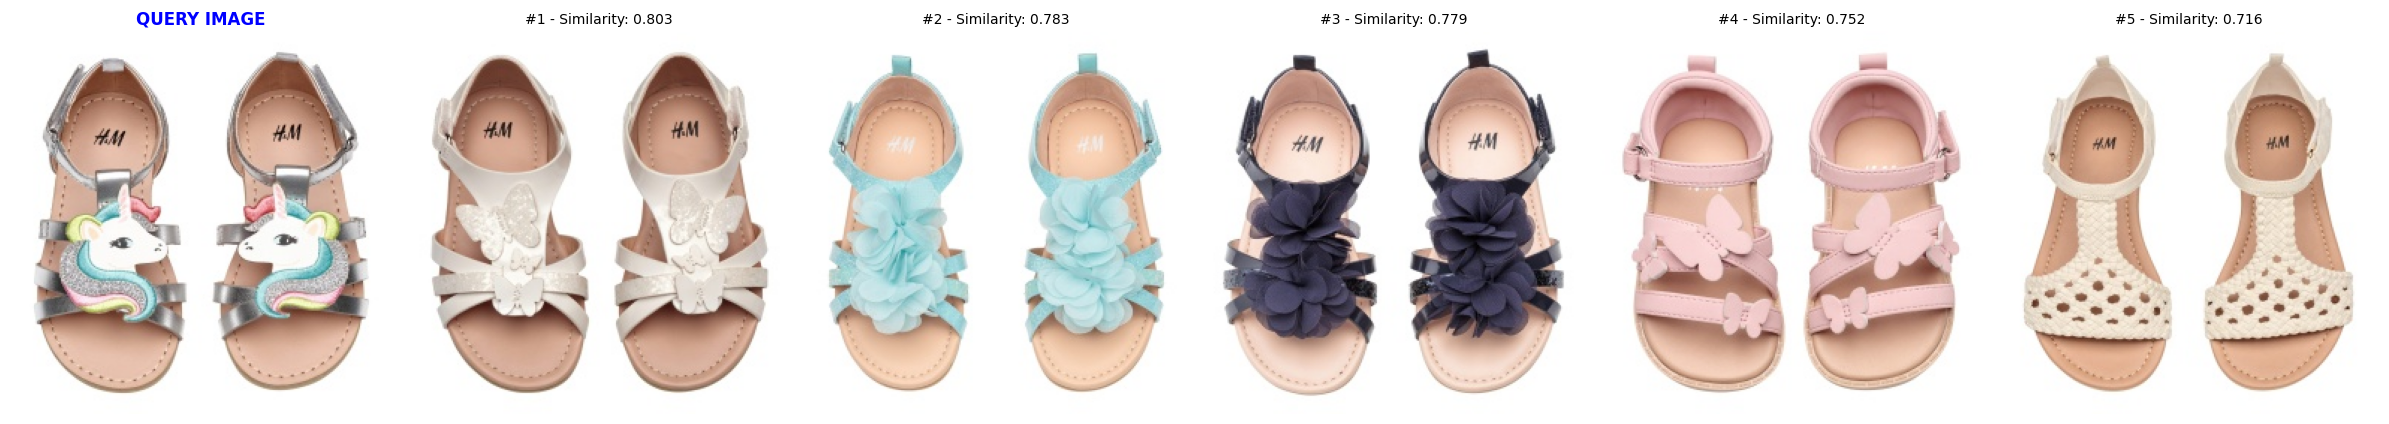


DETAILED RESULTS

#1 | Similarity: 0.8034
   Article ID: 562900001
   Name: CHLOE Fancy Sandal SG s7
   Type: Sandals
   Color: White
   Department: Kids Girl Shoes
   Category: Baby/Children

#2 | Similarity: 0.7833
   Article ID: 593426002
   Name: CHLOE fluff sandal SG
   Type: Sandals
   Color: Light Turquoise
   Department: Kids Girl Shoes
   Category: Baby/Children

#3 | Similarity: 0.7786
   Article ID: 593426003
   Name: CHLOE fluff sandal SG
   Type: Sandals
   Color: Dark Blue
   Department: Kids Girl Shoes
   Category: Baby/Children

#4 | Similarity: 0.7521
   Article ID: 616229003
   Name: Berry basic
   Type: Sandals
   Color: Light Pink
   Department: Baby Shoes
   Category: Baby/Children

#5 | Similarity: 0.7162
   Article ID: 593457003
   Name: Rhianna sandal BG
   Type: Sandals
   Color: Light Beige
   Department: Young Girl Shoes
   Category: Baby/Children


In [12]:
# Select a random image from dataset
np.random.seed(42)  # For reproducibility
random_idx = np.random.randint(0, len(filenames))
random_image = filenames[random_idx]
query_path = os.path.join(IMAGES_DIR, random_image)

print(f"Selected random image: {random_image}")
print()

# Search for similar shoes
results = search_similar_shoes(
    query_path,
    model,
    embeddings,
    filenames,
    df_articles_info
)

## Step 12: Demo - Search with Another Random Image

Try another random image to see different results.

Searching for images similar to: ../raw_data/images_filtered/0789734001.jpg
--------------------------------------------------
Extracting features from query image...
Searching among 5156 images...
Found 5 similar items!



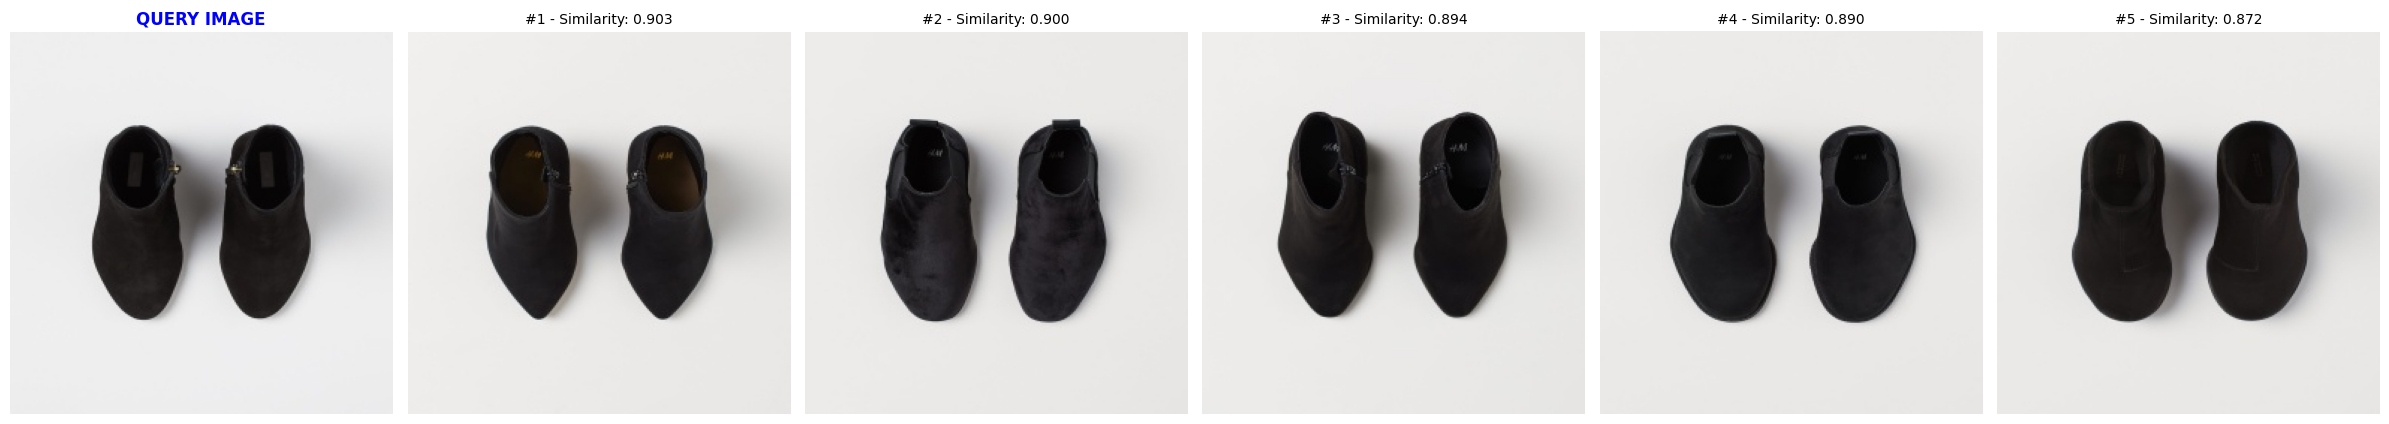


DETAILED RESULTS

#1 | Similarity: 0.9031
   Article ID: 795937001
   Name: Samira boot
   Type: Boots
   Color: Black
   Department: Boots
   Category: Ladieswear

#2 | Similarity: 0.8995
   Article ID: 647338011
   Name: Kobe Chelsea Boot
   Type: Boots
   Color: Black
   Department: Shoes / Boots inactive from s5
   Category: Menswear

#3 | Similarity: 0.8943
   Article ID: 672224001
   Name: Rubena
   Type: Boots
   Color: Black
   Department: Boots
   Category: Ladieswear

#4 | Similarity: 0.8897
   Article ID: 663382005
   Name: Winston chelsea boot
   Type: Boots
   Color: Black
   Department: Shoes / Boots inactive from s5
   Category: Menswear

#5 | Similarity: 0.8725
   Article ID: 806773001
   Name: Ling Platform
   Type: Boots
   Color: Black
   Department: Boots
   Category: Ladieswear


In [13]:
# Select another random image
random_idx = np.random.randint(0, len(filenames))
random_image = filenames[random_idx]
query_path = os.path.join(IMAGES_DIR, random_image)

# Search for similar shoes
results = search_similar_shoes(
    query_path,
    model,
    embeddings,
    filenames,
    df_articles_info
)

## Step 13: Search with Your Own Image

Test the similarity search with a custom shoe image.

**To use your own image:**
1. Place your image in `raw_data/test_images/` folder
2. Update the `custom_image_path` variable below with your filename
3. Run the cell

Found image: ../raw_data/test_images/test_shoe.jpg

Searching for images similar to: ../raw_data/test_images/test_shoe.jpg
--------------------------------------------------
Extracting features from query image...
Searching among 5156 images...
Found 5 similar items!



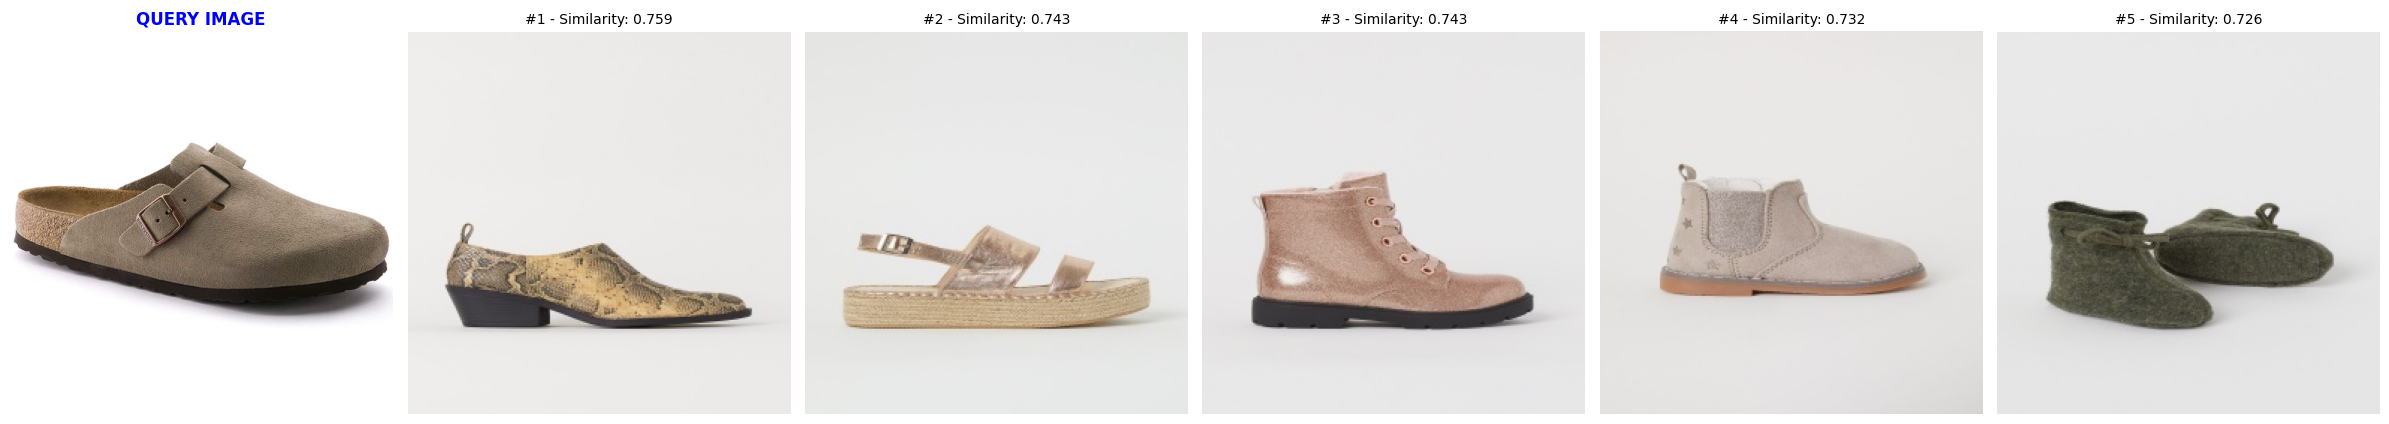


DETAILED RESULTS

#1 | Similarity: 0.7593
   Article ID: 709973001
   Name: Alma speed
   Type: Boots
   Color: Dark Orange
   Department: Divided Shoes
   Category: Divided

#2 | Similarity: 0.7430
   Article ID: 721435004
   Name: Love Espadrille
   Type: Sandals
   Color: Light Pink
   Department: Flats
   Category: Ladieswear

#3 | Similarity: 0.7426
   Article ID: 887552003
   Name: Blake boot SG
   Type: Boots
   Color: Bronze/Copper
   Department: Kids Girl Shoes
   Category: Baby/Children

#4 | Similarity: 0.7318
   Article ID: 624658004
   Name: Charlie boot
   Type: Boots
   Color: Beige
   Department: Baby Shoes
   Category: Baby/Children

#5 | Similarity: 0.7264
   Article ID: 947310001
   Name: TOMTE booties
   Type: Bootie
   Color: Dark Green
   Department: Baby Exclusive
   Category: Baby/Children


In [14]:
# Path to test image
custom_image_path = '../raw_data/test_images/test_shoe.jpg'

# Check if file exists and run search
if os.path.exists(custom_image_path):
    print(f"Found image: {custom_image_path}\n")
    results = search_similar_shoes(
        custom_image_path,
        model,
        embeddings,
        filenames,
        df_articles_info
    )
else:
    print(f"Image not found: {custom_image_path}")
    print("\nTo test with your own image:")
    print("1. Place your image in raw_data/test_images/")
    print("2. Update 'custom_image_path' above with the correct filename")

## Step 14: Interactive Search by Article ID

If you know the article ID, you can search directly using it.

In [15]:
def search_by_article_id(article_id, model, embeddings, filenames, df_articles, images_dir=IMAGES_DIR):
    """
    Search for similar shoes using article ID.

    Args:
        article_id: The article ID (integer)
    """
    # Convert article_id to filename
    filename = f"{str(article_id).zfill(10)}.jpg"

    if filename not in filenames:
        print(f"Article ID {article_id} not found in database.")
        return None

    query_path = os.path.join(images_dir, filename)
    return search_similar_shoes(query_path, model, embeddings, filenames, df_articles, images_dir)

# Example: Search by article ID
# Uncomment and change the article_id to try:
# search_by_article_id(181160009, model, embeddings, filenames, df_articles_info)

## Summary

This notebook implements a visual similarity search system for shoes:

**What we built:**
- Feature extraction using ResNet50 pretrained model
- Cosine similarity search with numpy
- Results display with product information

**Performance:**
- Embeddings are saved to disk for fast reuse
- Search is instant (~milliseconds) after embeddings are loaded
- Works with any shoe image (not just from dataset)

**Next steps to improve:**
- Add image augmentation for better robustness
- Try different models (EfficientNet, CLIP)
- Add category filtering (search only within "Sneakers")
- Build a web interface with Gradio or Streamlit